In [39]:
import numpy as np
import numpy.fft as fft
import matplotlib.pyplot as plt
from particlefield import get_params_from_scales

In [40]:
dx = 0.01
N = 4096
L = N * dx
x = np.arange(N)*dx
q = 2*np.pi*fft.fftfreq(N, d=dx)
q2 = q**2

In [70]:
mu = 1.0
field_length_scale = 0.01
field_time_scale = 1e-1
particle_time_scale = 1e-3
kappa = 50
r0 = 2.5
params = get_params_from_scales(field_length_scale, field_time_scale, particle_time_scale, mu, kappa)
gamma, K, gamma_tilde = params['gamma'], params['K'], params['gamma_tilde']

In [71]:
g_q = (1+field_length_scale**2*q2)*(field_length_scale**2*q2)/field_time_scale
V_x = np.exp(-0.5*(x**2)/r0**2)
V_x *= 1/(np.sum(V_x)*dx)
V_q = fft.fft(V_x)
kernel_prefactor = (q2)*np.conj(V_q)*V_q/(1+field_length_scale**2*q2)

In [89]:
v= 1.0
T_max = 2*L/(v)
t = np.linspace(0, T_max, 1000)
integrand = kernel_prefactor[None,:]*np.exp(-g_q[None,:]*t[:,None])
integrand *= np.exp(-1j*q[None,:]*v*t[:,None])
kernel = fft.ifft(integrand).real*dx
kernel *= field_time_scale/field_length_scale**2
kernel *= 1/(gamma*gamma_tilde)

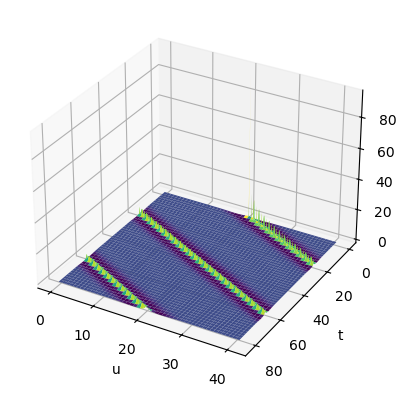

In [90]:
%matplotlib inline
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xx, tt = np.meshgrid(x, t, indexing='xy')
ax.plot_surface(xx, tt, fft.fftshift(kernel, axes=-1), cmap='viridis')
ax.invert_yaxis()
ax.set_xlabel('u')
ax.set_ylabel('t')
plt.show()